In [102]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [104]:
# Read file 
logon = pd.read_csv("logon.csv")
df.head()

,user,day,after_hours_logon_flag,usb_used_flag,urls_after_hours,is_suspicious
0,DTAA/AAA0371,2010-01-04,False,False,0.0,0
1,DTAA/AAA0371,2010-01-05,False,False,0.0,0
2,DTAA/AAA0371,2010-01-06,False,False,0.0,0
3,DTAA/AAA0371,2010-01-07,False,False,0.0,0
4,DTAA/AAA0371,2010-01-08,False,False,0.0,0


In [106]:
# Check for missing values
df.isnull().sum()

user                      0
day                       0
after_hours_logon_flag    0
usb_used_flag             0
urls_after_hours          0
is_suspicious             0
dtype: int64

In [108]:
# Convert string date to datetime format 
logon['date'] = pd.to_datetime(logon['date'])

In [110]:
# Creating a flag for after hours 
def is_after_hours(ts):
    return (ts.dt.hour < 7) | (ts.dt.hour > 18)

logon['after_hours_logon'] = is_after_hours(logon['date']) & (logon['activity'] == 'Logon')


In [112]:
# Group by hours and day 
after_hours_df = logon.groupby(['user', logon['date'].dt.date])['after_hours_logon'].any().reset_index()
after_hours_df.rename(columns={'after_hours_logon': 'after_hours_logon_flag', 'date': 'day'}, inplace=True)

# Label is just whether after-hours login occurred
after_hours_df['is_suspicious'] = after_hours_df['after_hours_logon_flag'].astype(int)

In [114]:
# Train split 
X = after_hours_df[['after_hours_logon_flag']]
y = after_hours_df['is_suspicious']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [116]:
# Logisitc Regression 
lr = LogisticRegression()
lr.fit(X_train, y_train)

print("Logistic Regression:\n")
print(classification_report(y_test, lr.predict(X_test)))

Logistic Regression:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     92552
           1       1.00      1.00      1.00      7920

    accuracy                           1.00    100472
   macro avg       1.00      1.00      1.00    100472
weighted avg       1.00      1.00      1.00    100472



In [118]:
# Random Forest 
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("Random Forest:\n")
print(classification_report(y_test, rf.predict(X_test)))


Random Forest:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     92552
           1       1.00      1.00      1.00      7920

    accuracy                           1.00    100472
   macro avg       1.00      1.00      1.00    100472
weighted avg       1.00      1.00      1.00    100472



In [119]:
# Decision Tree 
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

print("Decision Tree:\n")
print(classification_report(y_test, dt.predict(X_test)))


Decision Tree:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     92552
           1       1.00      1.00      1.00      7920

    accuracy                           1.00    100472
   macro avg       1.00      1.00      1.00    100472
weighted avg       1.00      1.00      1.00    100472



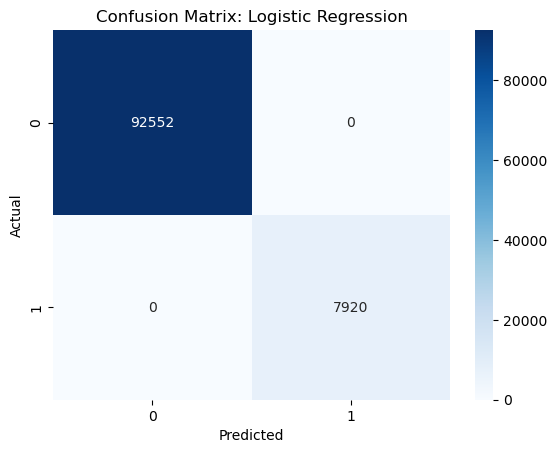

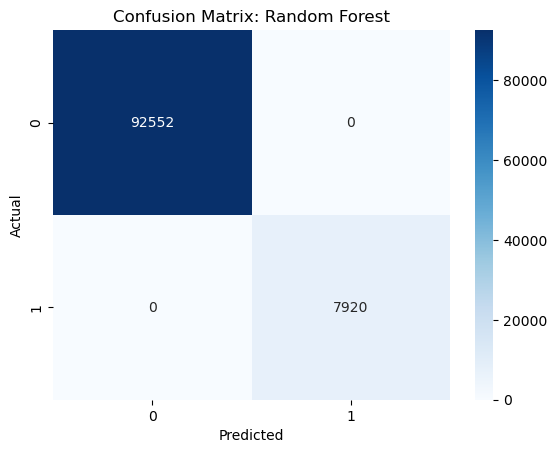

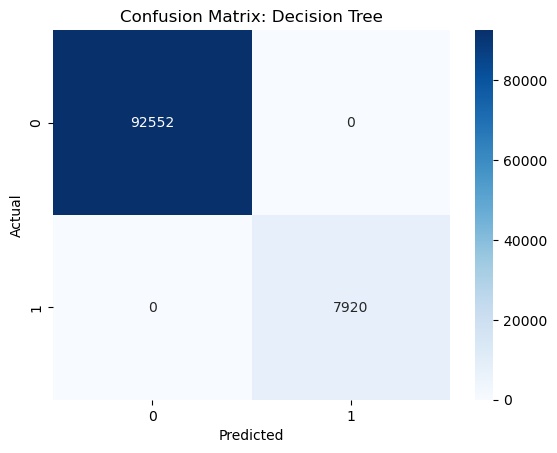

In [121]:
# Confusion matrix model and using heatmapping 
for model, name in zip([lr, rf, dt], ['Logistic Regression', 'Random Forest', 'Decision Tree']):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Summary stats:
                                  day  is_suspicious
count                         334905  334905.000000
mean   2010-09-04 05:31:08.607516160       0.078291
min              2010-01-04 00:00:00       0.000000
25%              2010-05-03 00:00:00       0.000000
50%              2010-09-01 00:00:00       0.000000
75%              2011-01-10 00:00:00       0.000000
max              2011-05-14 00:00:00       1.000000
std                              NaN       0.268629


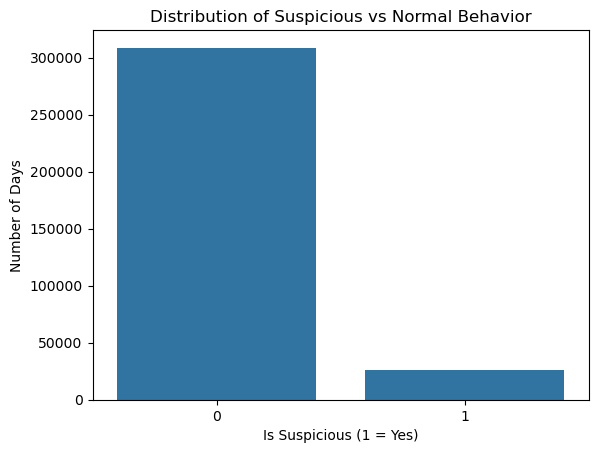

In [130]:
## Distribution of Suspicious vs Normal Behavior
print("Summary stats:\n", after_hours_df.describe())

# Class distribution
sns.countplot(x='is_suspicious', data=after_hours_df)
plt.title("Distribution of Suspicious vs Normal Behavior")
plt.xlabel("Is Suspicious (1 = Yes)")
plt.ylabel("Number of Days")
plt.show()


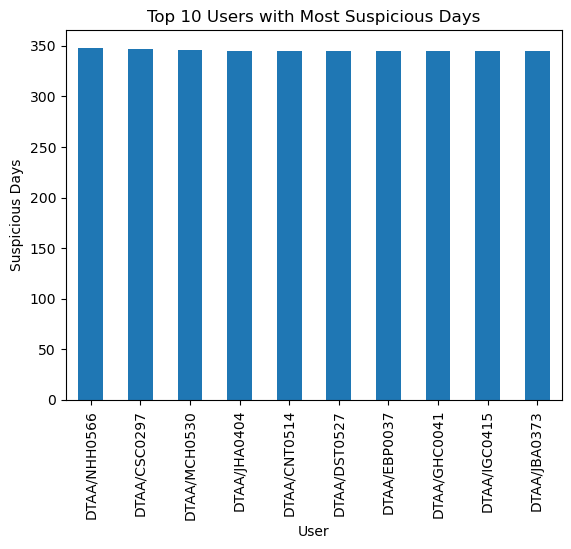

In [132]:
## Top 10 Users with Most Suspicious Days 
top_users = after_hours_df[after_hours_df['is_suspicious'] == 1]['user'].value_counts().head(10)
top_users.plot(kind='bar')
plt.title("Top 10 Users with Most Suspicious Days")
plt.xlabel("User")
plt.ylabel("Suspicious Days")
plt.show()


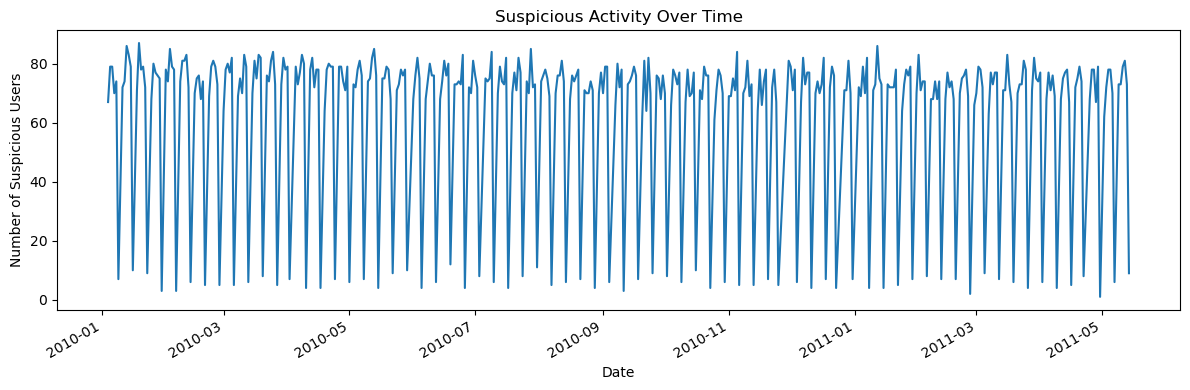

In [134]:
## Suspicious Activity Over Time
# Convert day column to datetime incase 
after_hours_df['day'] = pd.to_datetime(after_hours_df['day'])

# Count suspicious days by date
daily_counts = after_hours_df[after_hours_df['is_suspicious'] == 1].groupby('day').size()

plt.figure(figsize=(12, 4))
daily_counts.plot()
plt.title('Suspicious Activity Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Suspicious Users')
plt.tight_layout()
plt.show()

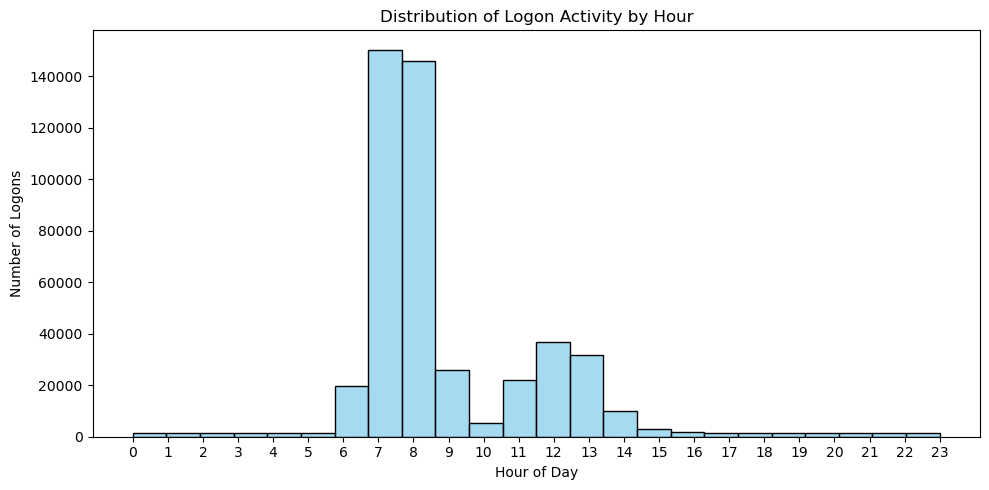

In [139]:
## Distribution of Logon Activity by Hour 

# extract hour from datetime
logon['hour'] = logon['date'].dt.hour
# filter for Logon events only
logons_only = logon[logon['activity'] == 'Logon']

# Plot histogram of logon hours
plt.figure(figsize=(10, 5))
sns.histplot(logons_only['hour'], bins=24, kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution of Logon Activity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Logons')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()